In [1]:
from Triangle.Constants import * 
from Triangle.FFTTools import *
from Triangle.TDI import *

from Triangle_BBH.Utils import * 
from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import * 

import matplotlib.pyplot as plt 

import numpy as np 
from tqdm import tqdm 

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


No pyseobnr.
no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Load Data
The data can be downloaded from [this link](https://zenodo.org/records/7436568).

### this function is AI-generated

In [2]:
import h5py
from typing import Optional

def print_hdf5_structure(obj, indent: int = 0, path: str = "/",
                         show_data: bool = False, max_items: int = 5,
                         max_depth: Optional[int] = None,
                         current_depth: int = 0) -> None:
    """
    递归打印HDF5对象的结构
    
    参数:
        obj: HDF5对象（文件、组或数据集）
        indent: 缩进级别
        path: 当前对象的路径
        show_data: 是否显示数据集内容
        max_items: 显示数组数据时的最大项目数
        max_depth: 最大递归深度（None表示无限制）
        current_depth: 当前递归深度
    """
    if max_depth is not None and current_depth > max_depth:
        return
    
    indent_str = "  " * indent
    
    if isinstance(obj, h5py.File):
        print(f"{indent_str}📁 File: {obj.filename}")
        print(f"{indent_str}  Mode: {obj.mode}")
    elif isinstance(obj, h5py.Group):
        print(f"{indent_str}📁 Group: {path}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent_str}📊 Dataset: {path}")
        print(f"{indent_str}  Shape: {obj.shape}")
        print(f"{indent_str}  Dtype: {obj.dtype}")
        print(f"{indent_str}  Size: {obj.size} elements")
        
        if show_data:
            try:
                data = obj[()]
                if isinstance(data, np.ndarray):
                    if data.size <= max_items:
                        print(f"{indent_str}  Data: {data}")
                    else:
                        # 显示前几个和后几个元素
                        flat_data = data.flatten()
                        preview = np.concatenate([
                            flat_data[:max_items//2],
                            flat_data[-max_items//2:]
                        ])
                        print(f"{indent_str}  Data (first & last {max_items//2}): {preview} ...")
                else:
                    print(f"{indent_str}  Data: {data}")
            except Exception as e:
                print(f"{indent_str}  Error reading data: {e}")
    
    # 如果是组或文件，递归遍历其内容
    if isinstance(obj, (h5py.File, h5py.Group)):
        for key in obj.keys():
            new_path = f"{path}/{key}" if path != "/" else f"/{key}"
            try:
                new_obj = obj[key]
                print_hdf5_structure(
                    new_obj, indent + 1, new_path, 
                    show_data, max_items, max_depth, current_depth + 1
                )
            except Exception as e:
                print(f"{indent_str}  ❌ Error accessing {key}: {e}")

### show structure 

In [3]:
h5f = h5py.File("/Users/taijidatacenter/workspace/LDCData/LDC2_spritz_mbhb1_training_v2.h5", "r") 
print_hdf5_structure(h5f)

📁 File: /Users/taijidatacenter/workspace/LDCData/LDC2_spritz_mbhb1_training_v2.h5
  Mode: r
  📁 Group: /clean
    📊 Dataset: /clean/tdi
      Shape: (535680, 1)
      Dtype: [('t', '<f8'), ('X', '<f8'), ('Y', '<f8'), ('Z', '<f8')]
      Size: 535680 elements
  📁 Group: /gal
    📊 Dataset: /gal/tdi
      Shape: (535680, 1)
      Dtype: [('t', '<f8'), ('X', '<f8'), ('Y', '<f8'), ('Z', '<f8')]
      Size: 535680 elements
  📁 Group: /header
    📊 Dataset: /header/date
      Shape: ()
      Dtype: object
      Size: 1 elements
  📁 Group: /instru
    📁 Group: /instru/config
      📊 Dataset: /instru/config/LISA_AAFILTER_ATTENUATION
        Shape: ()
        Dtype: int64
        Size: 1 elements
      📊 Dataset: /instru/config/LISA_AAFILTER_TRANSITION_BAND_0
        Shape: ()
        Dtype: float64
        Size: 1 elements
      📊 Dataset: /instru/config/LISA_AAFILTER_TRANSITION_BAND_1
        Shape: ()
        Dtype: float64
        Size: 1 elements
      📊 Dataset: /instru/config/LISA_ACC_NO

### convert to our convention 
according to the LDC manual 

In [4]:
lam = h5f["sky"]["cat"]["EclipticLongitude"] 
beta = h5f["sky"]["cat"]["EclipticLatitude"] 
theta_zS = h5f["sky"]["cat"]["InitialPolarAngleL"]
phi_zS = h5f["sky"]["cat"]["InitialAzimuthalAngleL"]
iota = np.arccos(-np.cos(theta_zS) * np.sin(beta) - np.cos(beta) * np.sin(theta_zS) * np.cos(phi_zS - lam))
psi = np.arctan2(-np.sin(beta) * np.sin(theta_zS) * np.cos(phi_zS - lam) + np.cos(beta) * np.cos(theta_zS), np.sin(theta_zS) * np.sin(lam - phi_zS))

In [5]:
injected_parameters = {
    "chirp_mass": Mc_m1_q(h5f["sky"]["cat"]["Mass1"], h5f["sky"]["cat"]["Mass2"] / h5f["sky"]["cat"]["Mass1"]), 
    "mass_ratio": h5f["sky"]["cat"]["Mass2"] / h5f["sky"]["cat"]["Mass1"], 
    "spin_1z": h5f["sky"]["cat"]["Spin1"] * np.cos(h5f["sky"]["cat"]["PolarAngleOfSpin1"]), 
    "spin_2z": h5f["sky"]["cat"]["Spin2"] * np.cos(h5f["sky"]["cat"]["PolarAngleOfSpin2"]), 
    "coalescence_time": h5f["sky"]["cat"]["CoalescenceTime"] / DAY, 
    "coalescence_phase": h5f["sky"]["cat"]["PhaseAtCoalescence"], 
    "luminosity_distance": h5f["sky"]["cat"]["Distance"],
    "inclination": iota,
    "longitude": lam, 
    "latitude": beta, 
    "psi": psi  
}

injected_parameters


{'chirp_mass': 772462.857152831,
 'mass_ratio': 0.46285493073209505,
 'spin_1z': 0.26863190922667673,
 'spin_2z': -0.4215109787709388,
 'coalescence_time': 133.41371437360257,
 'coalescence_phase': 1.2201968860015653,
 'luminosity_distance': 13470.983558972537,
 'inclination': 2.2517895222056112,
 'longitude': 1.2925183861048521,
 'latitude': -0.30300442294174235,
 'psi': -1.8503700516659007}

### show data in the time domain 

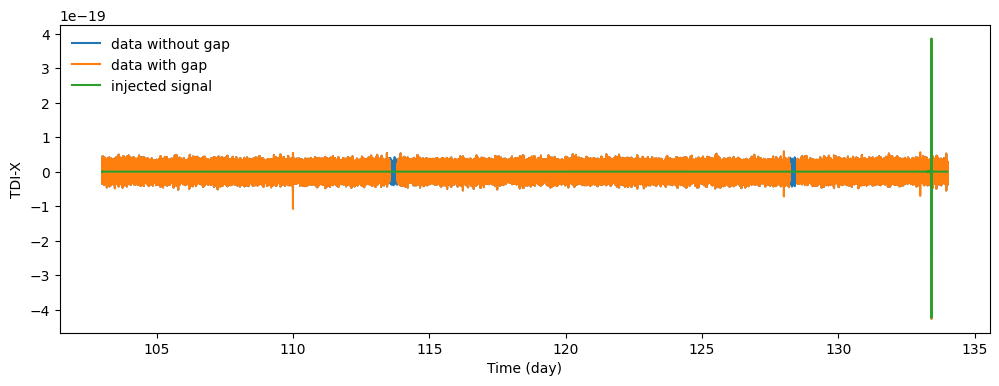

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(h5f["sky"]["tdi"]["t"][:, 0]/DAY, h5f["clean"]["tdi"]["X"][:, 0], label="data without gap")
plt.plot(h5f["sky"]["tdi"]["t"][:, 0]/DAY, h5f["obs"]["tdi"]["X"][:, 0], label = "data with gap")
plt.plot(h5f["sky"]["tdi"]["t"][:, 0]/DAY, h5f["sky"]["tdi"]["X"][:, 0], label = "injected signal")

plt.xlabel("Time (day)")
plt.ylabel("TDI-X")
plt.legend(loc="upper left", frameon=False)

### show data in the frequency domain 

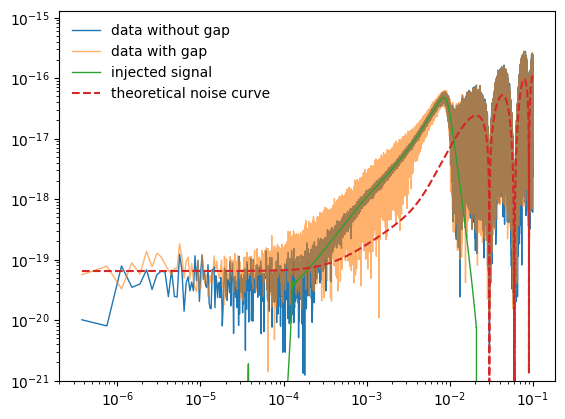

In [7]:
NBIN=1


ff, xf = FFT_window(
    data_array=h5f["clean"]["tdi"]["X"][:, 0], 
    fsample=1./(h5f["sky"]["tdi"]["t"][1, 0]-h5f["sky"]["tdi"]["t"][0, 0]), 
    window_type="tukey", 
    window_args_dict=dict(alpha=0.05), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="data without gap")

ff, xf = FFT_window(
    data_array=np.nan_to_num(h5f["obs"]["tdi"]["X"][:, 0], nan=0.), 
    fsample=1./(h5f["sky"]["tdi"]["t"][1, 0]-h5f["sky"]["tdi"]["t"][0, 0]), 
    window_type="tukey", 
    window_args_dict=dict(alpha=0.05), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="data with gap", alpha=0.6)

ff, xf = FFT_window(
    data_array=h5f["sky"]["tdi"]["X"][:, 0], 
    fsample=1./(h5f["sky"]["tdi"]["t"][1, 0]-h5f["sky"]["tdi"]["t"][0, 0]), 
    window_type="tukey", 
    window_args_dict=dict(alpha=0.05), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="injected signal")

PSDfunc = TDIPSDs(sacc=3e-15, sro=8e-12, L=2.5e9)
plt.loglog(ff, np.sqrt(PSDfunc.PSD_X2(ff) * (h5f["sky"]["tdi"]["t"][-1, 0]-h5f["sky"]["tdi"]["t"][0, 0]) / 2.), label="theoretical noise curve", linestyle="--")

plt.ylim(1e-21, )
plt.legend(loc="upper left", frameon=False)

## analyze the ``clean`` data 
with the approach demonstrated in example 4. 

### prepare TD and FD data 

In [8]:
data_time = h5f["sky"]["tdi"]["t"][:, 0]
A2_td, E2_td, _ = AETfromXYZ(h5f["clean"]["tdi"]["X"][:, 0], h5f["clean"]["tdi"]["Y"][:, 0], h5f["clean"]["tdi"]["Z"][:, 0])
data_channels_td = np.array([A2_td, E2_td]) 
channel_names = ["A2", "E2"] 

# use 5-day data containing the merger (while the data ends before tc+2.5day, so the resulting data segment is shorter than 5day)
time_idx = np.where(np.abs(data_time/DAY - injected_parameters["coalescence_time"])<2.5)[0]
data_time = data_time[time_idx]
data_channels_td = data_channels_td[:, time_idx]

dt = data_time[1] - data_time[0]
Tobs = len(data_time) * dt 

data_channels_fd = [] 
for i in range(len(data_channels_td)): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=1000./Tobs)
    )
    data_channels_fd.append(xf) 
data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0]) # shift to the "correct" time 
data_frequency = ff 

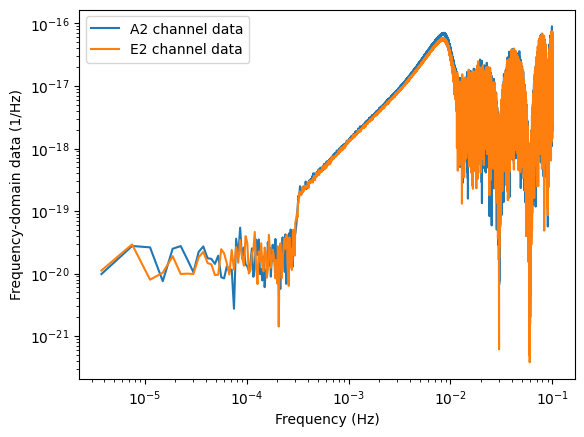

In [9]:
for ichan, chan in enumerate(channel_names): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[ichan]), label=f"{chan} channel data")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency-domain data (1/Hz)")
plt.legend()

In [10]:
FMIN = 1e-4 
FMAX = 2e-2 
freq_idx = np.where((data_frequency>=FMIN)&(data_frequency<=FMAX))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]

### set models 

In [11]:
# this orbit data is converted from the original .h5 orbit file of LDC 2b 
orbit = Orbit(OrbitDir="/Users/taijidatacenter/workspace/Triangle-Simulator/OrbitData/LDC2BOrbit")

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(mode="primary")

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(orbit_class=orbit, waveform_generator=WFG)

# response settings 
response_kwargs_interp = dict(
    fmin=FMIN, 
    fmax=FMAX,
    fref=1e-3,
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method='cubic',
)

# for simplicity we use the theoretical instrumental noise PSD
psd_channels = np.array([
    PSDfunc.PSD_A2(data_frequency), 
    PSDfunc.PSD_A2(data_frequency), 
])

# covariance matrix
CovMat = np.array([
    [psd_channels[0], np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_channels[1]],
]) / 4. * Tobs 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

response_kwargs_interp, InvCovMat.shape 

({'fmin': 0.0001,
  'fmax': 0.02,
  'fref': 0.001,
  'modes': [(2, 2)],
  'tmin': 130.91371527777778,
  'tmax': 133.99994212962963,
  'tref_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'drop_T': True,
  'interpolation_method': 'cubic'},
 (5307, 2, 2))

### initialize F-stat and set priors 

In [13]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False, 
)

lgMc_prior = [5., 7.]
q_prior = [0.01, 0.99]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [response_kwargs_interp["tmin"], response_kwargs_interp["tmax"]]
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### search for the intrinsice parameters 

In [14]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
        return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float
    except np.linalg.LinAlgError:
        return np.infty 

n_dim_int = len(intrinsic_param_priors) 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    maxiter=1000,
    popsize=5*n_dim_int,
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    workers=-1, 
)

DE_result

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2)
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:199: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), np.fabs(fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2))
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packag

             message: Optimization terminated successfully.
             success: True
                 fun: -6883487.239380278
                   x: [ 4.439e-01  4.658e-01  6.377e-01  2.935e-01
                        7.789e-01  2.056e-01  3.472e-01]
                 nit: 796
                nfev: 195265
          population: [[ 4.439e-01  4.658e-01 ...  2.056e-01  3.472e-01]
                       [ 4.439e-01  4.671e-01 ...  2.056e-01  3.530e-01]
                       ...
                       [ 4.439e-01  4.668e-01 ...  2.059e-01  3.561e-01]
                       [ 4.439e-01  4.668e-01 ...  2.057e-01  3.452e-01]]
 population_energies: [-6.883e+06 -6.883e+06 ... -6.883e+06 -6.883e+06]

### recover all source parameters 

In [19]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)
searched_parameters = dict(searched_int_params, **searched_ext_params)
searched_parameters_reflected = get_reflected_parameter_dict_Fref(searched_params=searched_parameters, orbit=orbit)
searched_wf_reflected = FDTDI.Response(
    parameters=searched_parameters_reflected, 
    freqs=data_frequency, 
    **response_kwargs_interp, 
)

print("injected location (longitude, latitude):", injected_parameters["longitude"], injected_parameters["latitude"])
print("searched location (longitude, latitude):", searched_parameters["longitude"], searched_parameters["latitude"])
print("reflected location (longitude, latitude):", searched_parameters_reflected["longitude"], searched_parameters_reflected["latitude"])

searched_wf = FDTDI.Response(
    searched_parameters, 
    data_frequency, 
    **response_kwargs_interp, 
)

injected location (longitude, latitude): 1.2925183861048521 -0.30300442294174235
searched location (longitude, latitude): 1.2920813610344073 -0.3106177976065037
reflected location (longitude, latitude): 0.14520248526408328 0.29589379205695804


### show searched waveform in frequency domain 

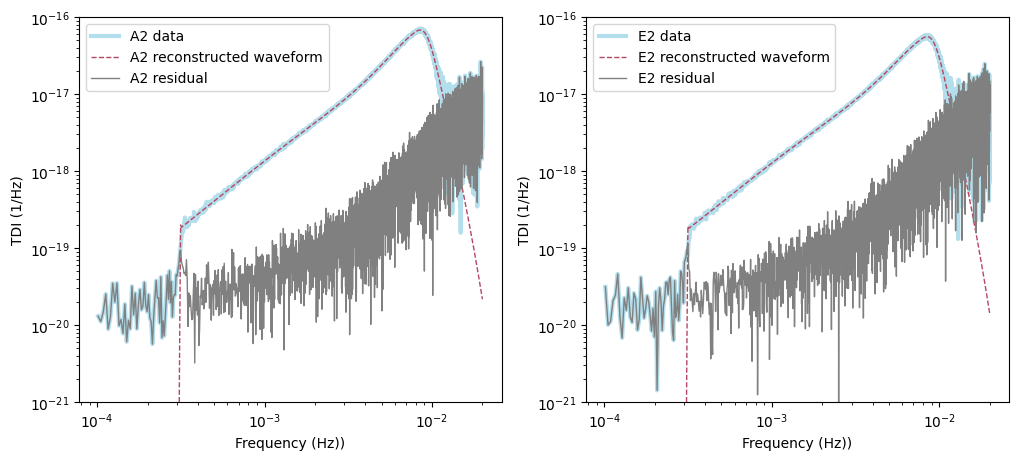

In [21]:
plt.figure(figsize=(12, 5))
for i in range(len(data_channels_fd)): 
    plt.subplot(121+i)
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data", color=BLUE, linewidth=3, alpha=0.5)
    plt.loglog(data_frequency, np.abs(searched_wf[i]), label=channel_names[i]+" reconstructed waveform", color=RED, linewidth=1, linestyle="--")
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]-searched_wf[i]), label=channel_names[i]+" residual", color="grey", linewidth=1)
    plt.xlabel("Frequency (Hz))")
    plt.ylabel("TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.ylim(1e-21, 1e-16)